# Analisis Spotify Dataset
## Prediksi Popularitas & Estimasi Streams

**Part 1** — Klasifikasi popularitas (High/Low) dengan **Logistic Regression**  
**Part 2** — Regresi jumlah Streams dengan **Random Forest** & **LightGBM**

### Perbaikan dari versi sebelumnya
| Masalah lama | Perbaikan |
|---|---|
| Audio features tidak dipakai | Danceability, Energy, Loudness, dll. kini jadi fitur |
| Bug regresi: X_train/y_train dari klasifikasi | Regresi kini punya split sendiri |
| `FutureWarning` pandas inplace | Diganti assignment langsung |
| `pd.get_dummies` pada raw Genre string | Diganti `ast.literal_eval` + binary flags |
| Tidak ada StandardScaler | Ditambahkan untuk Logistic Regression |
| Multikolinearitas release_year & song_age_years | song_age_years dihapus |
| Hanya 200 baris | Seluruh 1556 baris digunakan |
| `global` variables | Dihapus, variabel mengalir natural antar cell |

In [1]:
import pandas as pd
import numpy as np
import ast
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 50)
print("Import selesai.")

Import selesai.


## Bagian 0: Load Dataset & Eksplorasi Awal

In [2]:
df_raw = pd.read_csv('spotify_dataset.csv')
print(f"Shape dataset: {df_raw.shape}")
print("\nTipe data kolom:")
print(df_raw.dtypes)
print("\nMissing values per kolom:")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.any() else "Tidak ada missing values")
print("\nRingkasan statistik kolom numerik:")
df_raw.select_dtypes(include='number').describe().round(2)

Shape dataset: (1556, 23)

Tipe data kolom:
Index                        int64
Highest Charting Position    int64
Number of Times Charted      int64
Week of Highest Charting       str
Song Name                      str
Streams                        str
Artist                         str
Artist Followers               str
Song ID                        str
Genre                          str
Release Date                   str
Weeks Charted                  str
Popularity                     str
Danceability                   str
Energy                         str
Loudness                       str
Speechiness                    str
Acousticness                   str
Liveness                       str
Tempo                          str
Duration (ms)                  str
Valence                        str
Chord                          str
dtype: object

Missing values per kolom:
Tidak ada missing values

Ringkasan statistik kolom numerik:


,Index,Highest Charting Position,Number of Times Charted
count,1556.00,1556.00,1556.00
mean,778.50,87.74,10.67
std,449.32,58.15,16.36
min,1.00,1.00,1.00
25%,389.75,37.00,1.00
50%,778.50,80.00,4.00
75%,1167.25,137.00,12.00
max,1556.00,200.00,142.00


## Bagian 1: Pembersihan Data

- **Streams** & **Artist Followers**: hapus koma, konversi ke float
- **Audio features** (Danceability, Energy, Loudness, dll.): konversi ke numerik
- **Popularity**: konversi ke numerik
- **Release Date**: ekstrak tahun & bulan, hapus kolom asli
- **Kolom non-prediktif** (Index, Song ID, Artist, Song Name, dll.): dihapus

In [3]:
df = df_raw.copy()

# Hapus kolom non-prediktif
drop_cols = ['Index', 'Song ID', 'Week of Highest Charting',
             'Artist', 'Song Name', 'Weeks Charted', 'Chord']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Streams: hapus koma -> float
df['Streams'] = (
    df['Streams']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Artist Followers: hapus koma, ekstrak angka -> float
df['Artist Followers'] = (
    df['Artist Followers']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .str.extract(r'(\d+)', expand=False)
    .astype(float)
)

# Audio features & Popularity: hapus koma jika ada -> numerik
audio_and_pop = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)',
    'Valence', 'Popularity'
]
for col in audio_and_pop:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .pipe(pd.to_numeric, errors='coerce')
        )

# Release Date -> year & month (hapus song_age_years: kolinear dengan release_year)
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['release_year']  = df['Release Date'].dt.year
df['release_month'] = df['Release Date'].dt.month
df = df.drop(columns=['Release Date'])

print(f"Shape setelah pembersihan: {df.shape}")
print("\nTipe data setelah pembersihan:")
print(df.dtypes)
print("\nMissing values setelah pembersihan:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "Tidak ada missing values")

Shape setelah pembersihan: (1556, 17)

Tipe data setelah pembersihan:
Highest Charting Position      int64
Number of Times Charted        int64
Streams                      float64
Artist Followers             float64
Genre                            str
Popularity                   float64
Danceability                 float64
Energy                       float64
Loudness                     float64
Speechiness                  float64
Acousticness                 float64
Liveness                     float64
Tempo                        float64
Duration (ms)                float64
Valence                      float64
release_year                 float64
release_month                float64
dtype: object

Missing values setelah pembersihan:
Artist Followers    11
Popularity          11
Danceability        11
Energy              11
Loudness            11
Speechiness         11
Acousticness        11
Liveness            11
Tempo               11
Duration (ms)       11
Valence             

## Bagian 2: Feature Engineering

### Genre
Kolom `Genre` berisi string representasi list Python seperti `"['pop', 'dance pop']"`.  
Sebelumnya `pd.get_dummies` dipakai langsung — ini salah karena membuat 130 kolom dengan nama seperti `Genre_['pop', 'dance pop']` (satu kolom per kombinasi unik, bukan per genre).  
**Perbaikan**: parse dengan `ast.literal_eval`, lalu buat binary flag untuk top-10 genre.

In [4]:
def safe_literal_eval(x):
    if not isinstance(x, str):
        return []
    try:
        result = ast.literal_eval(x)
        return result if isinstance(result, list) else [result]
    except (ValueError, SyntaxError):
        return []

df['_genre_list'] = df['Genre'].apply(safe_literal_eval)

# Hitung frekuensi tiap genre individual
genre_counter = Counter(g for genres in df['_genre_list'] for g in genres)

TOP_N_GENRES = 10
top_genres = [g for g, _ in genre_counter.most_common(TOP_N_GENRES)]
print(f"Top {TOP_N_GENRES} genre: {top_genres}")

# Binary flag per genre
for genre in top_genres:
    df[f'genre_{genre}'] = df['_genre_list'].apply(lambda x: int(genre in x))

df = df.drop(columns=['Genre', '_genre_list'])
print(f"Shape setelah genre encoding: {df.shape}")
print(f"Contoh kolom genre: {[c for c in df.columns if c.startswith('genre_')]}")

Top 10 genre: ['pop', 'rap', 'dance pop', 'post-teen pop', 'pop rap', 'trap', 'reggaeton', 'trap latino', 'latin', 'hip hop']
Shape setelah genre encoding: (1556, 26)
Contoh kolom genre: ['genre_pop', 'genre_rap', 'genre_dance pop', 'genre_post-teen pop', 'genre_pop rap', 'genre_trap', 'genre_reggaeton', 'genre_trap latino', 'genre_latin', 'genre_hip hop']


In [5]:
print("=== Imputasi Missing Values (median) ===")
for col in df.select_dtypes(include='number').columns:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)   # perbaikan FutureWarning: tidak pakai inplace
        print(f"  '{col}': {n_missing} missing -> diisi median = {median_val:.4f}")

remaining = df.isnull().sum().sum()
print(f"\nTotal missing values tersisa: {remaining}")
print(f"Shape final dataset: {df.shape}")

=== Imputasi Missing Values (median) ===
  'Artist Followers': 11 missing -> diisi median = 6852509.0000
  'Popularity': 11 missing -> diisi median = 73.0000
  'Danceability': 11 missing -> diisi median = 0.7070
  'Energy': 11 missing -> diisi median = 0.6420
  'Loudness': 11 missing -> diisi median = -5.9900
  'Speechiness': 11 missing -> diisi median = 0.0765
  'Acousticness': 11 missing -> diisi median = 0.1610
  'Liveness': 11 missing -> diisi median = 0.1240
  'Tempo': 11 missing -> diisi median = 122.0120
  'Duration (ms)': 11 missing -> diisi median = 193591.0000
  'Valence': 11 missing -> diisi median = 0.5120
  'release_year': 28 missing -> diisi median = 2020.0000
  'release_month': 28 missing -> diisi median = 6.0000

Total missing values tersisa: 0
Shape final dataset: (1556, 26)


---
## Part 1: Klasifikasi Popularitas (Logistic Regression)

**Target**: `Popularity_High` — 1 jika Popularity >= median, 0 jika tidak  
**Fitur**: semua kolom numerik kecuali `Popularity`, `Popularity_High`, `Streams`  
**Tambahan**: `StandardScaler` untuk normalisasi fitur sebelum regresi logistik

In [6]:
# Target variable
median_pop = df['Popularity'].median()
df['Popularity_High'] = (df['Popularity'] >= median_pop).astype(int)

print(f"Threshold popularitas (median): {median_pop}")
print("\nDistribusi kelas:")
vc = df['Popularity_High'].value_counts()
print(f"  High (1): {vc.get(1, 0)} baris ({vc.get(1, 0)/len(df)*100:.1f}%)")
print(f"  Low  (0): {vc.get(0, 0)} baris ({vc.get(0, 0)/len(df)*100:.1f}%)")

# Pilih fitur
EXCLUDE_CLS = {'Popularity', 'Popularity_High', 'Streams'}
cls_features = [c for c in df.select_dtypes(include='number').columns
                if c not in EXCLUDE_CLS]
print(f"\nJumlah fitur: {len(cls_features)}")
print(f"Fitur: {cls_features}")

X_cls = df[cls_features].copy()
y_cls = df['Popularity_High'].copy()

# Train-test split dengan stratify
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# StandardScaler
scaler = StandardScaler()
X_cls_train_s = scaler.fit_transform(X_cls_train)
X_cls_test_s  = scaler.transform(X_cls_test)

print(f"\nTrain: {X_cls_train.shape} | Test: {X_cls_test.shape}")

Threshold popularitas (median): 73.0

Distribusi kelas:
  High (1): 804 baris (51.7%)
  Low  (0): 752 baris (48.3%)

Jumlah fitur: 24
Fitur: ['Highest Charting Position', 'Number of Times Charted', 'Artist Followers', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'release_year', 'release_month', 'genre_pop', 'genre_rap', 'genre_dance pop', 'genre_post-teen pop', 'genre_pop rap', 'genre_trap', 'genre_reggaeton', 'genre_trap latino', 'genre_latin', 'genre_hip hop']

Train: (1244, 24) | Test: (312, 24)


In [7]:
log_reg = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
log_reg.fit(X_cls_train_s, y_cls_train)

y_pred_cls  = log_reg.predict(X_cls_test_s)
y_proba_cls = log_reg.predict_proba(X_cls_test_s)[:, 1]

acc     = accuracy_score(y_cls_test, y_pred_cls)
prec    = precision_score(y_cls_test, y_pred_cls, zero_division=0)
rec     = recall_score(y_cls_test, y_pred_cls, zero_division=0)
f1      = f1_score(y_cls_test, y_pred_cls, zero_division=0)
roc_auc = roc_auc_score(y_cls_test, y_proba_cls)
cm      = confusion_matrix(y_cls_test, y_pred_cls)
tn, fp, fn, tp = cm.ravel()

print("=== Evaluasi Logistic Regression ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nDetail:")
print(f"  True Positive  (TP) = {tp}: diprediksi High, benar High")
print(f"  True Negative  (TN) = {tn}: diprediksi Low,  benar Low")
print(f"  False Positive (FP) = {fp}: diprediksi High, padahal Low")
print(f"  False Negative (FN) = {fn}: diprediksi Low,  padahal High")

=== Evaluasi Logistic Regression ===
Accuracy : 0.6891
Precision: 0.7424
Recall   : 0.6087
F1-Score : 0.6689
ROC-AUC  : 0.7586

Confusion Matrix:
[[117  34]
 [ 63  98]]

Detail:
  True Positive  (TP) = 98: diprediksi High, benar High
  True Negative  (TN) = 117: diprediksi Low,  benar Low
  False Positive (FP) = 34: diprediksi High, padahal Low
  False Negative (FN) = 63: diprediksi Low,  padahal High


In [8]:
# P-value menggunakan statsmodels
# Perbaikan: pakai scaled X + reset index untuk menghindari singular matrix
X_sm = sm.add_constant(
    pd.DataFrame(X_cls_train_s, columns=cls_features)
)

try:
    logit_sm = sm.Logit(y_cls_train.values, X_sm.values)
    result_sm = logit_sm.fit(disp=False, maxiter=300)

    coef_df = pd.DataFrame({
        'Feature'    : ['const'] + cls_features,
        'Coefficient': result_sm.params,
        'P-value'    : result_sm.pvalues,
        'Signifikan' : result_sm.pvalues < 0.05,
    }).sort_values('P-value').reset_index(drop=True)

    print("=== Koefisien & P-value (Statsmodels Logit) ===")
    print(coef_df.to_string(index=False))
    sig = coef_df[coef_df['Signifikan']]['Feature'].tolist()
    print(f"\nFitur signifikan (p < 0.05): {sig}")
except Exception as e:
    print(f"Statsmodels error: {e}")
    print("Coba periksa multikolinearitas antar fitur.")

=== Koefisien & P-value (Statsmodels Logit) ===
                  Feature  Coefficient      P-value  Signifikan
  Number of Times Charted     2.246369 2.763940e-27        True
                    const     0.517305 4.578526e-08        True
      genre_post-teen pop    -0.436339 4.183747e-05        True
                 Liveness    -0.267991 3.690855e-04        True
                genre_pop     0.396305 1.233664e-03        True
                 Loudness     0.313460 6.279092e-03        True
             Danceability    -0.226991 8.935224e-03        True
         Artist Followers    -0.166210 6.597264e-02       False
              Speechiness    -0.120541 1.333328e-01       False
                    Tempo    -0.100141 1.484579e-01       False
             release_year     0.117998 1.491825e-01       False
               genre_trap    -0.133259 1.664486e-01       False
              genre_latin    -0.497584 1.899635e-01       False
          genre_reggaeton     0.440194 2.697857e-01     

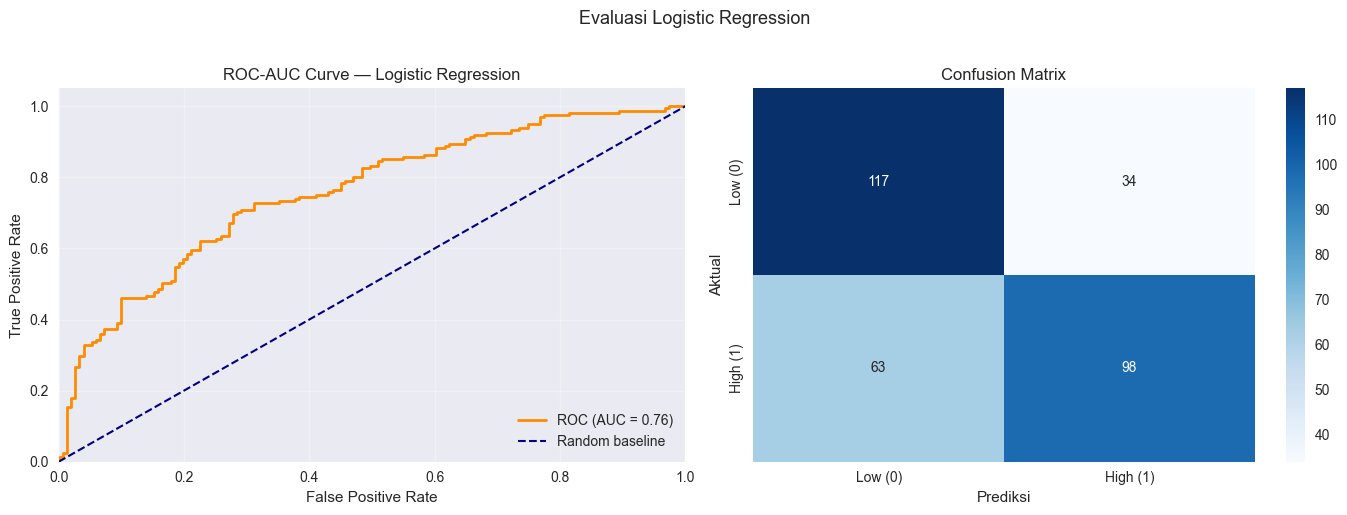

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_cls_test, y_proba_cls)
axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], 'navy', lw=1.5, linestyle='--',
             label='Random baseline')
axes[0].set(
    xlabel='False Positive Rate', ylabel='True Positive Rate',
    title='ROC-AUC Curve — Logistic Regression',
    xlim=[0, 1], ylim=[0, 1.05]
)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Confusion Matrix Heatmap
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
    xticklabels=['Low (0)', 'High (1)'],
    yticklabels=['Low (0)', 'High (1)']
)
axes[1].set(xlabel='Prediksi', ylabel='Aktual', title='Confusion Matrix')

plt.suptitle('Evaluasi Logistic Regression', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

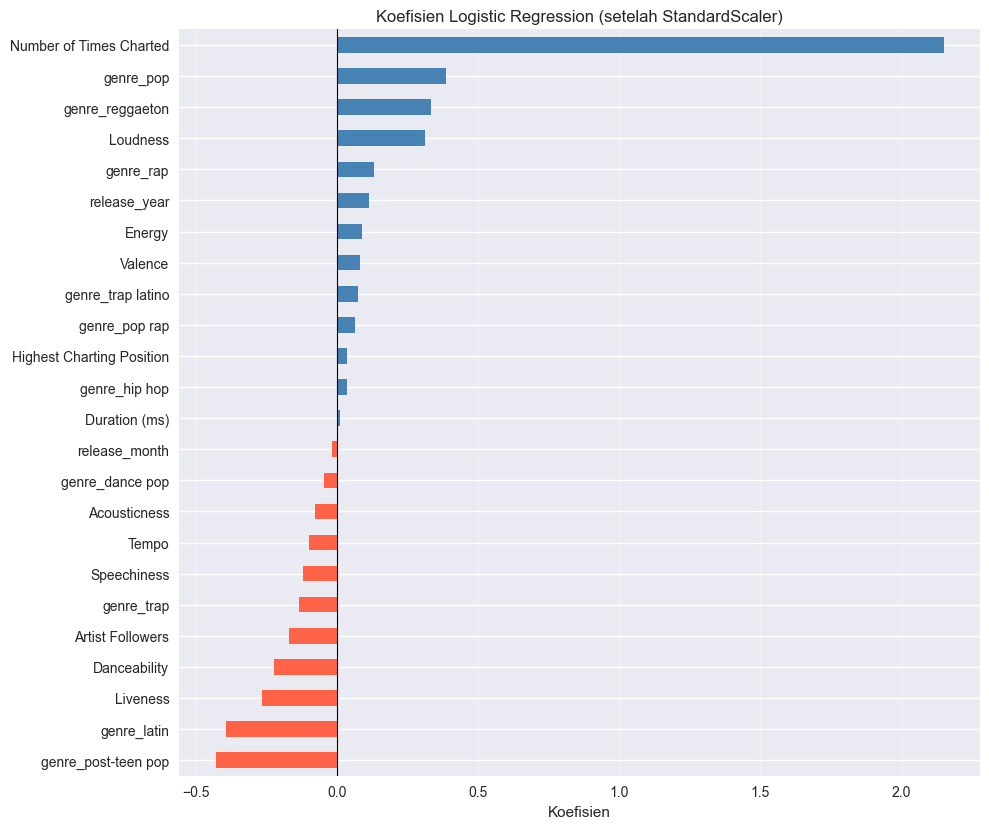

Biru  = koefisien positif -> meningkatkan probabilitas High Popularity
Merah = koefisien negatif -> menurunkan probabilitas High Popularity


In [10]:
coef_series = pd.Series(log_reg.coef_[0], index=cls_features).sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in coef_series]

fig, ax = plt.subplots(figsize=(10, max(5, len(cls_features) * 0.35)))
coef_series.plot(kind='barh', color=colors, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(
    title='Koefisien Logistic Regression (setelah StandardScaler)',
    xlabel='Koefisien'
)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Biru  = koefisien positif -> meningkatkan probabilitas High Popularity")
print("Merah = koefisien negatif -> menurunkan probabilitas High Popularity")

---
## Part 2: Regresi Streams (Random Forest + LightGBM)

**Target**: jumlah `Streams` (log-transform `log1p` untuk normalisasi distribusi skewed)

**Bug yang diperbaiki**: versi sebelumnya menggunakan `X_train`/`y_train` dari task klasifikasi (label 0/1) untuk melatih model regresi — ini menyebabkan model dilatih dengan target yang sepenuhnya salah. Kini dilakukan split ulang khusus regresi.

In [11]:
# Popularity boleh jadi fitur untuk regresi (bukan target)
# Popularity_High dikecualikan karena turunan dari Popularity (redundant)
EXCLUDE_REG = {'Streams', 'Popularity_High'}
reg_features = [c for c in df.select_dtypes(include='number').columns
                if c not in EXCLUDE_REG]

X_reg = df[reg_features].copy()
y_reg = np.log1p(df['Streams'])   # log1p untuk menormalisasi distribusi skewed

# Split khusus untuk regresi (independen dari split klasifikasi)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
y_reg_test_orig = np.expm1(y_reg_test)   # skala asli untuk evaluasi

print(f"Regression features ({len(reg_features)}): {reg_features}")
print(f"\nTrain: {X_reg_train.shape} | Test: {X_reg_test.shape}")
print(f"Target log(Streams): min={y_reg_train.min():.2f}, max={y_reg_train.max():.2f}")
print(f"Streams asli: min={np.expm1(y_reg_train.min()):,.0f}, max={np.expm1(y_reg_train.max()):,.0f}")

Regression features (25): ['Highest Charting Position', 'Number of Times Charted', 'Artist Followers', 'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence', 'release_year', 'release_month', 'genre_pop', 'genre_rap', 'genre_dance pop', 'genre_post-teen pop', 'genre_pop rap', 'genre_trap', 'genre_reggaeton', 'genre_trap latino', 'genre_latin', 'genre_hip hop']

Train: (1244, 25) | Test: (312, 25)
Target log(Streams): min=15.24, max=17.70
Streams asli: min=4,176,083, max=48,633,449


In [12]:
param_grid_rf = {
    'n_estimators'    : [100, 200],
    'max_features'    : ['sqrt', 0.8],
    'min_samples_leaf': [1, 2],
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0,
)

print("Melatih Random Forest dengan GridSearchCV...")
grid_rf.fit(X_reg_train, y_reg_train)
best_rf = grid_rf.best_estimator_
print(f"Best params: {grid_rf.best_params_}")

y_pred_rf_log = best_rf.predict(X_reg_test)
y_pred_rf     = np.expm1(y_pred_rf_log)

mae_rf  = mean_absolute_error(y_reg_test_orig, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_reg_test_orig, y_pred_rf))
r2_rf   = r2_score(y_reg_test_orig, y_pred_rf)

print(f"\n=== Random Forest (Tuned) ===")
print(f"MAE : {mae_rf:>15,.0f} streams")
print(f"RMSE: {rmse_rf:>15,.0f} streams")
print(f"R2  : {r2_rf:>15.4f}")

Melatih Random Forest dengan GridSearchCV...
Best params: {'max_features': 0.8, 'min_samples_leaf': 2, 'n_estimators': 200}

=== Random Forest (Tuned) ===
MAE :         686,653 streams
RMSE:       1,757,618 streams
R2  :          0.5130


In [13]:
lgbm = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

print("Melatih LightGBM...")
lgbm.fit(X_reg_train, y_reg_train)
print("Selesai.")

y_pred_lgbm_log = lgbm.predict(X_reg_test)
y_pred_lgbm     = np.expm1(y_pred_lgbm_log)

mae_lgbm  = mean_absolute_error(y_reg_test_orig, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_reg_test_orig, y_pred_lgbm))
r2_lgbm   = r2_score(y_reg_test_orig, y_pred_lgbm)

print(f"\n=== LightGBM ===")
print(f"MAE : {mae_lgbm:>15,.0f} streams")
print(f"RMSE: {rmse_lgbm:>15,.0f} streams")
print(f"R2  : {r2_lgbm:>15.4f}")

header = f"{'Model':<25} {'MAE':>12} {'RMSE':>12} {'R2':>8}"
print(f"\n{header}")
print("-" * 60)
print(f"{'Random Forest (Tuned)':<25} {mae_rf:>12,.0f} {rmse_rf:>12,.0f} {r2_rf:>8.4f}")
print(f"{'LightGBM':<25} {mae_lgbm:>12,.0f} {rmse_lgbm:>12,.0f} {r2_lgbm:>8.4f}")

Melatih LightGBM...
Selesai.

=== LightGBM ===
MAE :         686,477 streams
RMSE:       1,812,821 streams
R2  :          0.4819

Model                              MAE         RMSE       R2
------------------------------------------------------------
Random Forest (Tuned)          686,653    1,757,618   0.5130
LightGBM                       686,477    1,812,821   0.4819


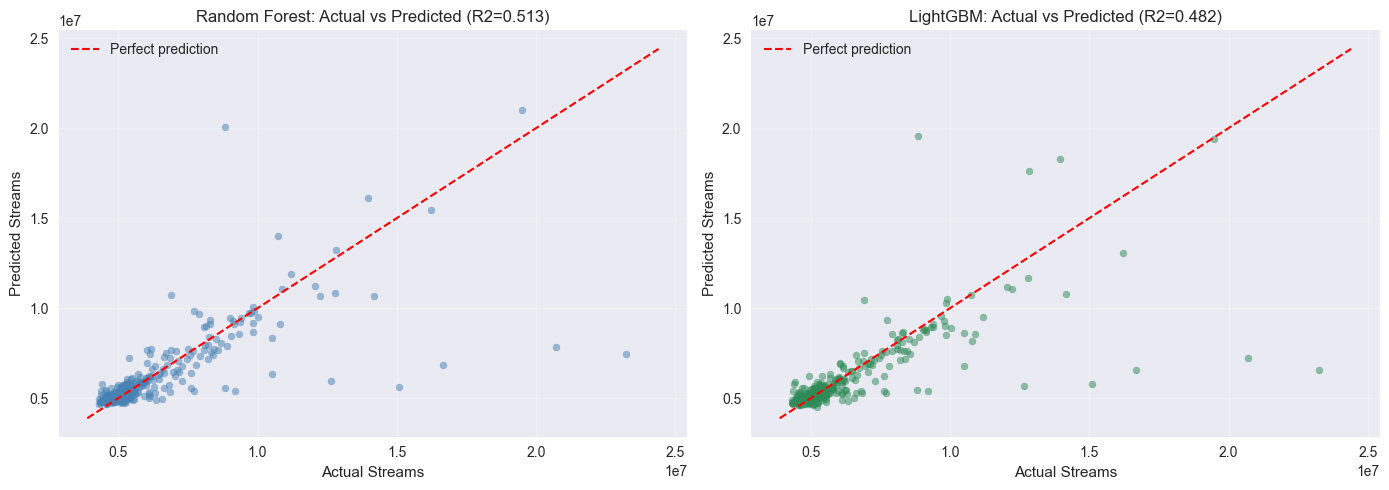

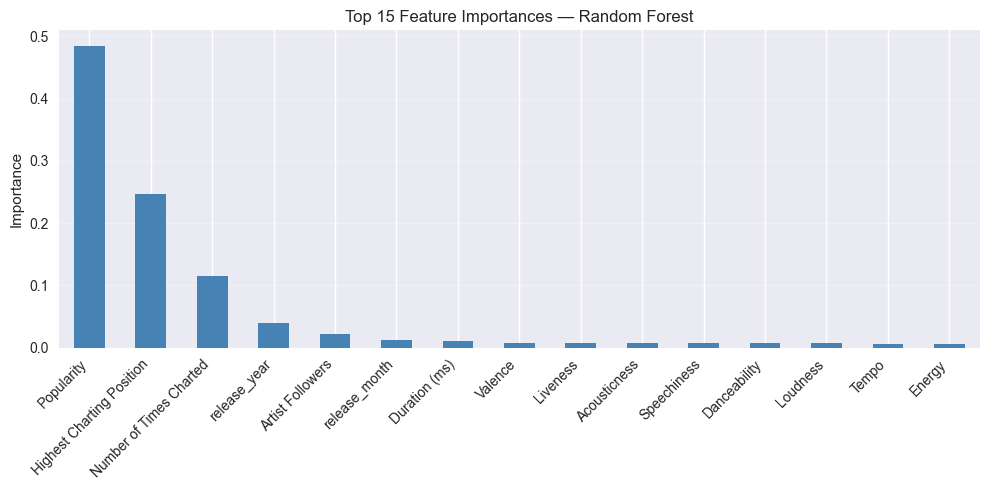

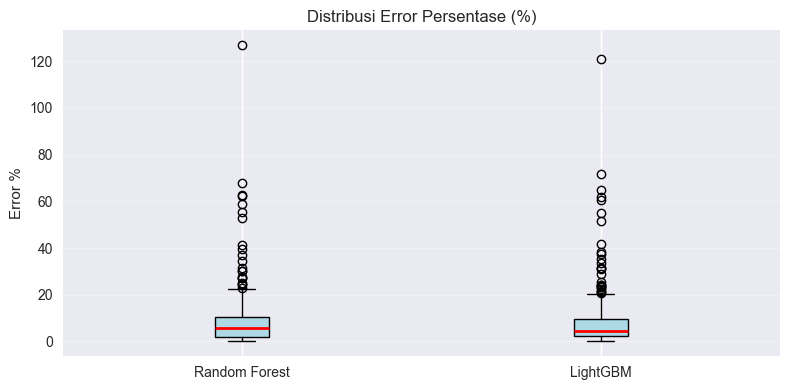

Median error % — RF: 5.6% | LGBM: 4.7%


In [14]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, name, color, r2 in [
    (axes[0], y_pred_rf,   'Random Forest', 'steelblue', r2_rf),
    (axes[1], y_pred_lgbm, 'LightGBM',      'seagreen',  r2_lgbm),
]:
    ax.scatter(y_reg_test_orig, y_pred, alpha=0.5, color=color, s=25)
    lo = y_reg_test_orig.min() * 0.9
    hi = y_reg_test_orig.max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect prediction')
    ax.set(
        xlabel='Actual Streams', ylabel='Predicted Streams',
        title=f'{name}: Actual vs Predicted (R2={r2:.3f})'
    )
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance (Random Forest)
feat_imp = pd.Series(
    best_rf.feature_importances_, index=reg_features
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Feature Importances — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Error distribution
rf_err   = np.abs(y_pred_rf   - y_reg_test_orig) / y_reg_test_orig * 100
lgbm_err = np.abs(y_pred_lgbm - y_reg_test_orig) / y_reg_test_orig * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([rf_err, lgbm_err], labels=['Random Forest', 'LightGBM'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set(title='Distribusi Error Persentase (%)', ylabel='Error %')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Median error % — RF: {rf_err.median():.1f}% | LGBM: {lgbm_err.median():.1f}%")

---
## Part 3: Fungsi Prediksi

Dua fungsi tersedia untuk inference pada data baru:
- `predict_popularity()` — prediksi High/Low + probabilitas (Logistic Regression)
- `predict_streams()` — estimasi jumlah streams (Random Forest)

In [15]:
def predict_popularity(
    highest_charting_position,
    number_of_times_charted,
    artist_followers,
    release_year,
    release_month,
    genres,
    danceability=None,
    energy=None,
    loudness=None,
    speechiness=None,
    acousticness=None,
    liveness=None,
    tempo=None,
    duration_ms=None,
    valence=None,
):
    # Prediksi High/Low popularity menggunakan Logistic Regression yang sudah dilatih.
    # Nilai audio yang tidak diberikan akan menggunakan median dari data training.
    defaults = {col: float(X_cls_train[col].median()) for col in cls_features}

    defaults.update({
        'Highest Charting Position': highest_charting_position,
        'Number of Times Charted'  : number_of_times_charted,
        'Artist Followers'         : artist_followers,
        'release_year'             : release_year,
        'release_month'            : release_month,
    })

    audio_map = {
        'Danceability' : danceability,
        'Energy'       : energy,
        'Loudness'     : loudness,
        'Speechiness'  : speechiness,
        'Acousticness' : acousticness,
        'Liveness'     : liveness,
        'Tempo'        : tempo,
        'Duration (ms)': duration_ms,
        'Valence'      : valence,
    }
    for col_name, val in audio_map.items():
        if val is not None and col_name in defaults:
            defaults[col_name] = val

    for g in top_genres:
        defaults[f'genre_{g}'] = int(g in genres)

    input_df = pd.DataFrame([defaults], columns=cls_features)
    input_s  = scaler.transform(input_df)

    pred_class = int(log_reg.predict(input_s)[0])
    pred_proba = float(log_reg.predict_proba(input_s)[0, 1])

    return {
        'popularity_category': 'High' if pred_class == 1 else 'Low',
        'probability_high'   : round(pred_proba, 4),
    }


def predict_streams(
    highest_charting_position,
    number_of_times_charted,
    artist_followers,
    release_year,
    release_month,
    genres,
):
    # Estimasi jumlah Streams menggunakan Random Forest yang sudah dilatih.
    defaults = {col: float(X_reg_train[col].median()) for col in reg_features}

    defaults.update({
        'Highest Charting Position': highest_charting_position,
        'Number of Times Charted'  : number_of_times_charted,
        'Artist Followers'         : artist_followers,
        'release_year'             : release_year,
        'release_month'            : release_month,
    })

    for g in top_genres:
        key = f'genre_{g}'
        if key in defaults:
            defaults[key] = int(g in genres)

    input_df     = pd.DataFrame([defaults], columns=reg_features)
    pred_streams = float(np.expm1(best_rf.predict(input_df)[0]))

    return {'predicted_streams': int(round(pred_streams))}

In [16]:
# Demo prediksi dengan contoh lagu baru
input_baru = dict(
    highest_charting_position=5,
    number_of_times_charted=10,
    artist_followers=10_000_000,
    release_year=2022,
    release_month=6,
    genres=['pop', 'hip hop'],
)
audio_baru = dict(
    danceability=0.72,
    energy=0.80,
    loudness=-5.5,
    speechiness=0.08,
    acousticness=0.15,
    liveness=0.12,
    tempo=125.0,
    duration_ms=195_000,
    valence=0.55,
)

result_cls = predict_popularity(**input_baru, **audio_baru)
result_reg = predict_streams(**input_baru)

print("=== Input ===")
for k, v in {**input_baru, **audio_baru}.items():
    print(f"  {k:<30}: {v}")

print("\n=== Hasil Prediksi ===")
print(f"  Kategori Popularitas : {result_cls['popularity_category']}")
print(f"  Probabilitas High    : {result_cls['probability_high']:.2%}")
print(f"  Estimasi Streams     : {result_reg['predicted_streams']:,}")

=== Input ===
  highest_charting_position     : 5
  number_of_times_charted       : 10
  artist_followers              : 10000000
  release_year                  : 2022
  release_month                 : 6
  genres                        : ['pop', 'hip hop']
  danceability                  : 0.72
  energy                        : 0.8
  loudness                      : -5.5
  speechiness                   : 0.08
  acousticness                  : 0.15
  liveness                      : 0.12
  tempo                         : 125.0
  duration_ms                   : 195000
  valence                       : 0.55

=== Hasil Prediksi ===
  Kategori Popularitas : High
  Probabilitas High    : 83.47%
  Estimasi Streams     : 5,543,734
